In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../Data/Health index.csv')

In [3]:
df.head()

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index
0,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,30.0
1,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,30.0
2,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,30.0
3,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,58.4
4,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,60.0


In [4]:
# Adding new Transformer column 
df.insert(0, 'Transformer_ID', ['TX_' + str(i) for i in range(1, len(df)+1)])
df.head()

,Transformer_ID,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index
0,TX_1,2845,5860,27842,7406,32,1344,16684,5467,7,19.0,1.00,45,55,0,30.0
1,TX_2,12886,61,25041,877,83,864,4,305,0,45.0,1.00,45,55,0,30.0
2,TX_3,2820,16400,56300,144,257,1080,206,11,2190,1.0,1.00,39,52,11,30.0
3,TX_4,1099,70,37520,545,184,1402,6,230,0,87.0,4.58,33,49,5,58.4
4,TX_5,3210,3570,47900,160,360,2130,4,43,4,1.0,0.77,44,55,3,60.0


In [5]:
df.columns = df.columns.str.strip()
df.columns

Index(['Transformer_ID', 'Hydrogen', 'Oxigen', 'Nitrogen', 'Methane', 'CO',
       'CO2', 'Ethylene', 'Ethane', 'Acethylene', 'DBDS', 'Power factor',
       'Interfacial V', 'Dielectric rigidity', 'Water content',
       'Health index'],
      dtype='object')

# EDA

In [6]:
df.shape

(470, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470 entries, 0 to 469
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transformer_ID       470 non-null    object 
 1   Hydrogen             470 non-null    int64  
 2   Oxigen               470 non-null    int64  
 3   Nitrogen             470 non-null    int64  
 4   Methane              470 non-null    int64  
 5   CO                   470 non-null    int64  
 6   CO2                  470 non-null    int64  
 7   Ethylene             470 non-null    int64  
 8   Ethane               470 non-null    int64  
 9   Acethylene           470 non-null    int64  
 10  DBDS                 470 non-null    float64
 11  Power factor         470 non-null    float64
 12  Interfacial V        470 non-null    int64  
 13  Dielectric rigidity  470 non-null    int64  
 14  Water content        470 non-null    int64  
 15  Health index         470 non-null    flo

In [8]:
df.describe()

,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index
count,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000,470.000000
mean,404.261702,8357.372340,47759.561702,79.695745,244.000000,1816.414894,162.923404,81.940426,91.491489,17.036596,1.849043,38.434043,53.495745,16.282979,89.145319
std,2002.142678,14164.233283,13760.451816,489.320336,237.267485,2256.790519,1323.811504,342.573636,644.365828,46.735057,6.144009,6.178830,6.458906,17.115646,15.039794
min,0.000000,57.000000,3600.000000,0.000000,10.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.050000,21.000000,27.000000,0.000000,30.000000
25%,4.000000,496.000000,41700.000000,2.000000,66.000000,641.750000,0.000000,0.000000,0.000000,0.000000,0.570000,32.000000,51.000000,5.000000,89.500000
50%,9.000000,3810.000000,49100.000000,3.000000,150.500000,1125.000000,3.000000,4.000000,0.000000,0.000000,1.000000,39.000000,54.000000,12.000000,93.800000
75%,34.000000,14875.000000,55875.000000,7.000000,361.750000,2257.500000,6.000000,69.750000,0.000000,2.000000,1.000000,44.000000,56.000000,21.000000,97.200000
max,23349.000000,249900.000000,85300.000000,7406.000000,1730.000000,24900.000000,16684.000000,5467.000000,9740.000000,227.000000,73.200000,57.000000,75.000000,183.000000,100.000000


In [9]:
df["Health index"].describe()

count    470.000000
mean      89.145319
std       15.039794
min       30.000000
25%       89.500000
50%       93.800000
75%       97.200000
max      100.000000
Name: Health index, dtype: float64

In [10]:
df.isnull().sum()

Transformer_ID         0
Hydrogen               0
Oxigen                 0
Nitrogen               0
Methane                0
CO                     0
CO2                    0
Ethylene               0
Ethane                 0
Acethylene             0
DBDS                   0
Power factor           0
Interfacial V          0
Dielectric rigidity    0
Water content          0
Health index           0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## _Distribution of Health Index_

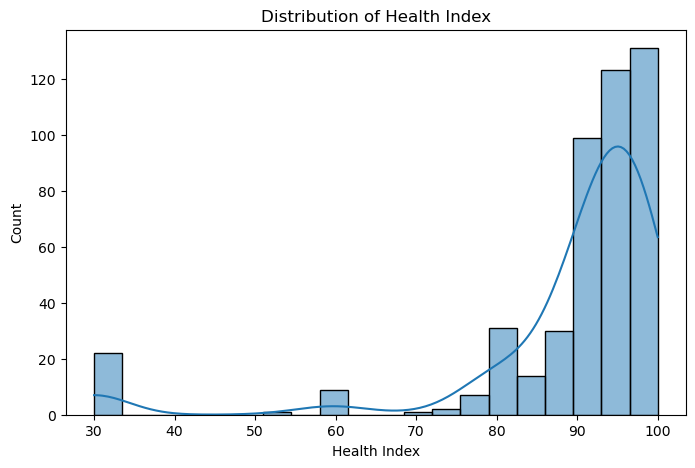

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Health index'], bins=20, kde=True, edgecolor="black")
plt.xlabel("Health Index")
plt.ylabel("Count")
plt.title("Distribution of Health Index")
plt.show()

In [13]:
df["Health index"].value_counts(bins=20).sort_index()

(29.929, 33.5]     22
(33.5, 37.0]        0
(37.0, 40.5]        0
(40.5, 44.0]        0
(44.0, 47.5]        0
(47.5, 51.0]        0
(51.0, 54.5]        1
(54.5, 58.0]        0
(58.0, 61.5]        9
(61.5, 65.0]        0
(65.0, 68.5]        1
(68.5, 72.0]        0
(72.0, 75.5]        2
(75.5, 79.0]        8
(79.0, 82.5]       30
(82.5, 86.0]       14
(86.0, 89.5]       33
(89.5, 93.0]       97
(93.0, 96.5]      127
(96.5, 100.0]     126
Name: count, dtype: int64

## _Correlation analysis_

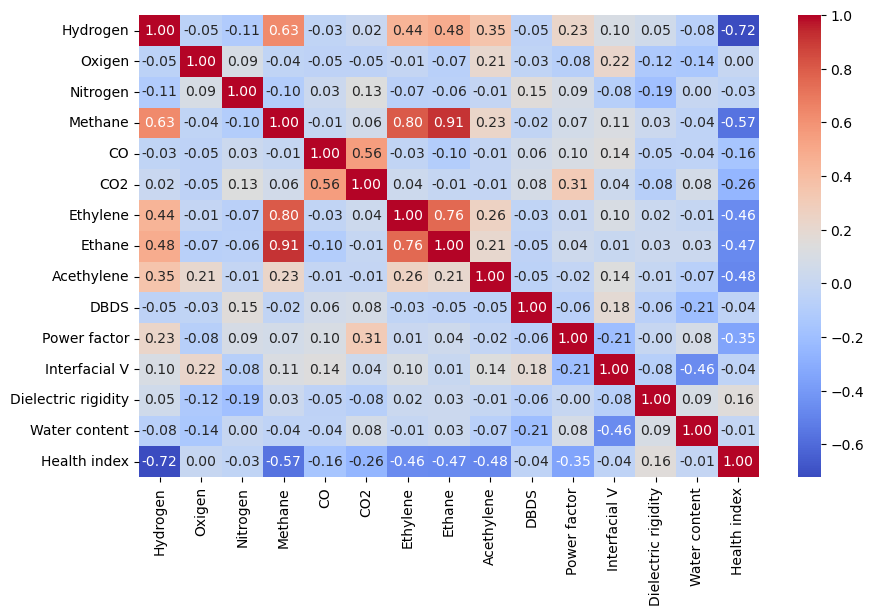

In [15]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## _Correlation with Health Index only_

In [32]:
corr['Health index'].sort_values()

Hydrogen              -0.722076
Methane               -0.566999
Acethylene            -0.483558
Ethane                -0.469562
Ethylene              -0.460064
Power factor          -0.351835
CO2                   -0.255477
CO                    -0.158643
DBDS                  -0.042532
Interfacial V         -0.037435
Nitrogen              -0.031668
Water content         -0.010024
Oxigen                 0.000159
Dielectric rigidity    0.157329
Health index           1.000000
Name: Health index, dtype: float64

## Boxplots for outlier detection

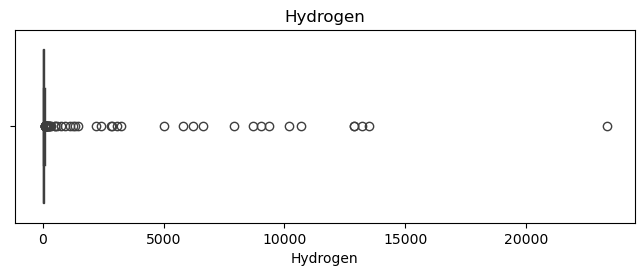

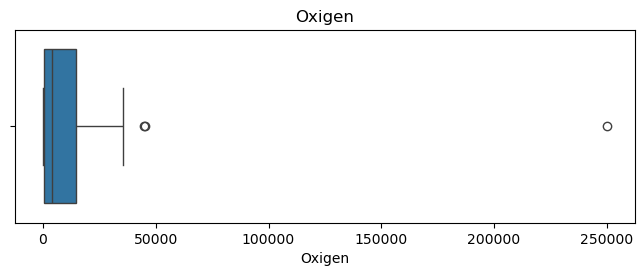

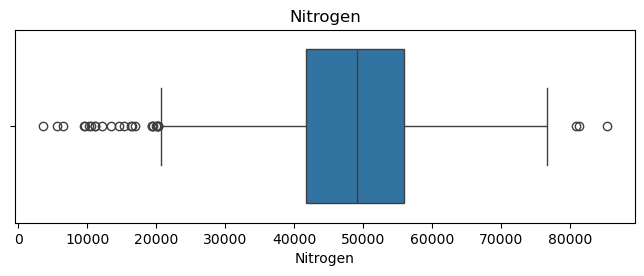

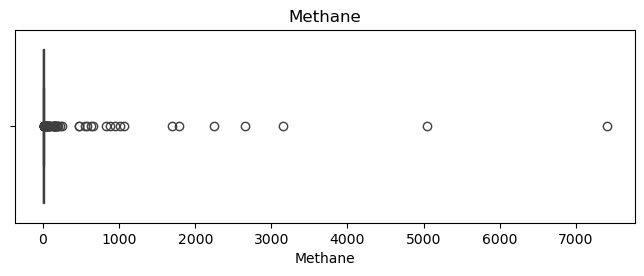

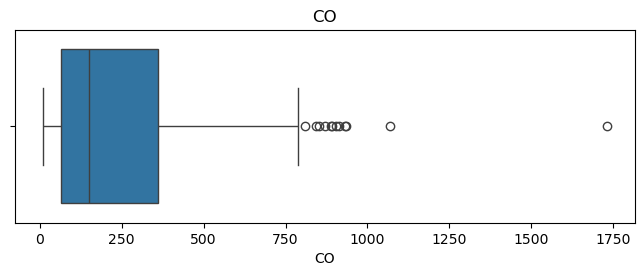

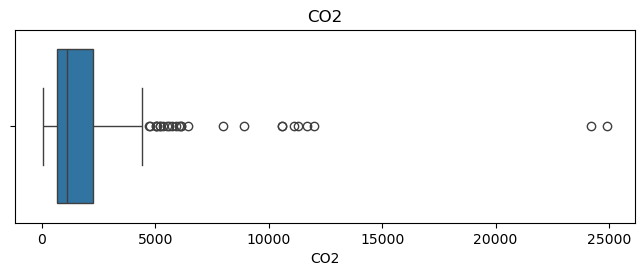

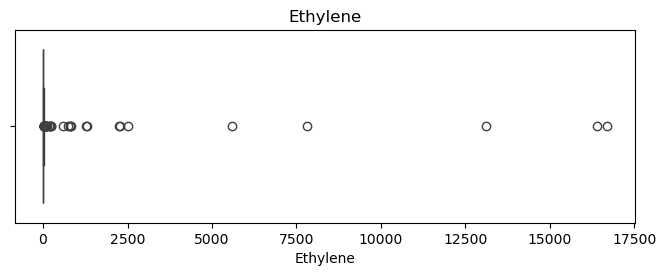

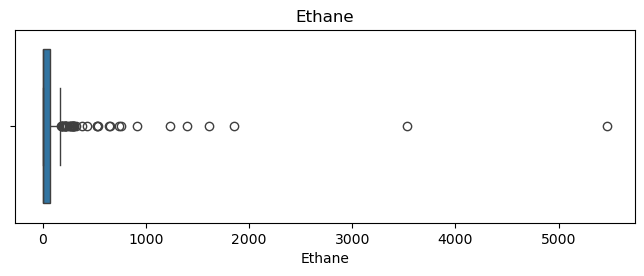

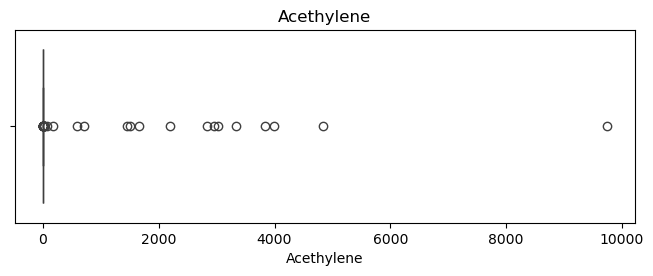

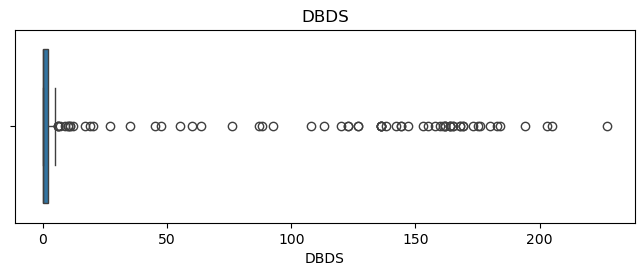

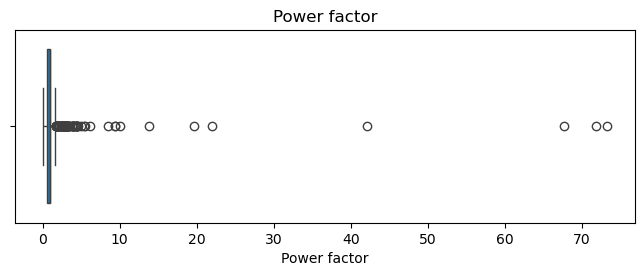

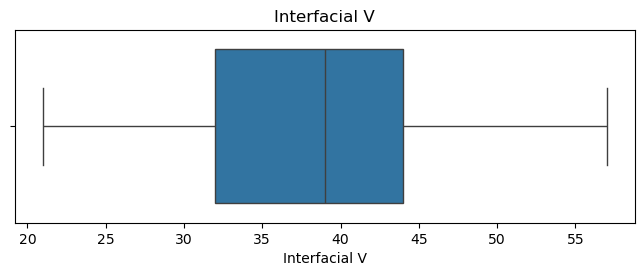

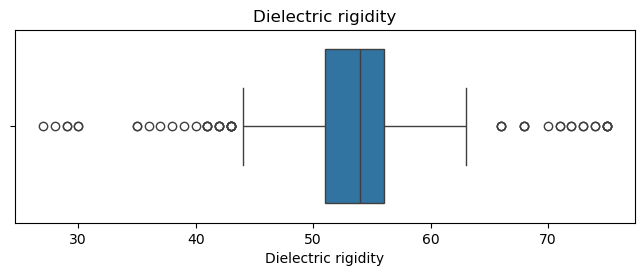

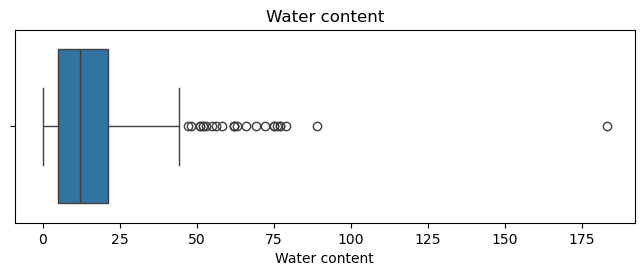

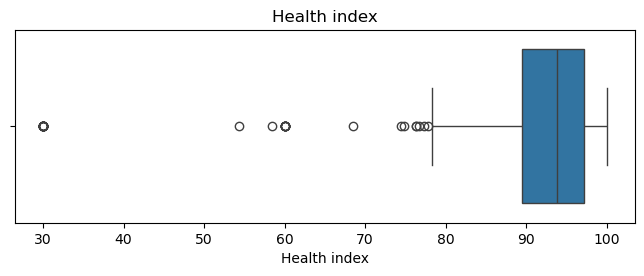

In [33]:
for col in df.columns[1:]:
    plt.figure(figsize=(8,2.5))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Dissolved Gas Analysis (DGA)

In [35]:
gas_cols = [
    'Hydrogen',
    'Oxigen',
    'Nitrogen',
    'Methane',
    'CO',
    'CO2',
    'Ethylene',
    'Ethane',
    'Acethylene'
]
df[gas_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Hydrogen,470.0,404.261702,2002.142678,0.0,4.00,9.0,34.00,23349.0
Oxigen,470.0,8357.372340,14164.233283,57.0,496.00,3810.0,14875.00,249900.0
Nitrogen,470.0,47759.561702,13760.451816,3600.0,41700.00,49100.0,55875.00,85300.0
Methane,470.0,79.695745,489.320336,0.0,2.00,3.0,7.00,7406.0
CO,470.0,244.000000,237.267485,10.0,66.00,150.5,361.75,1730.0
CO2,470.0,1816.414894,2256.790519,48.0,641.75,1125.0,2257.50,24900.0
Ethylene,470.0,162.923404,1323.811504,0.0,0.00,3.0,6.00,16684.0
Ethane,470.0,81.940426,342.573636,0.0,0.00,4.0,69.75,5467.0
Acethylene,470.0,91.491489,644.365828,0.0,0.00,0.0,0.00,9740.0


### _Distribution of DGA Gases_

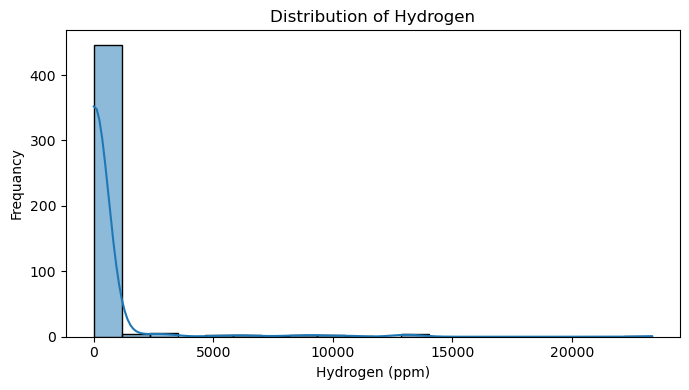

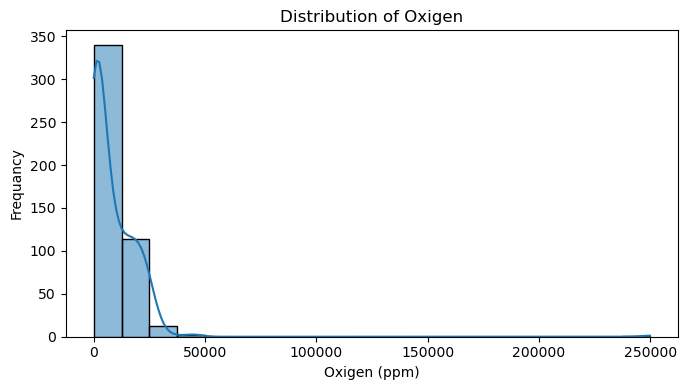

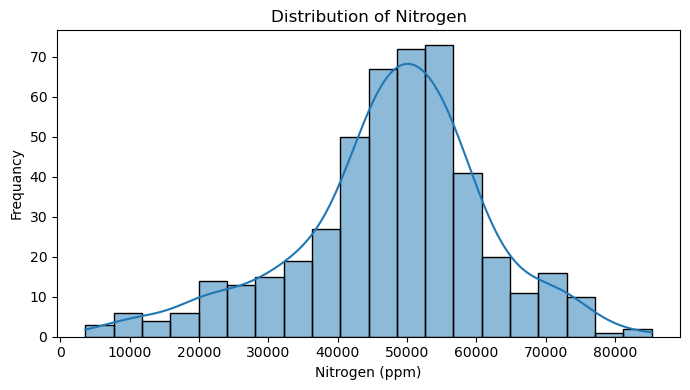

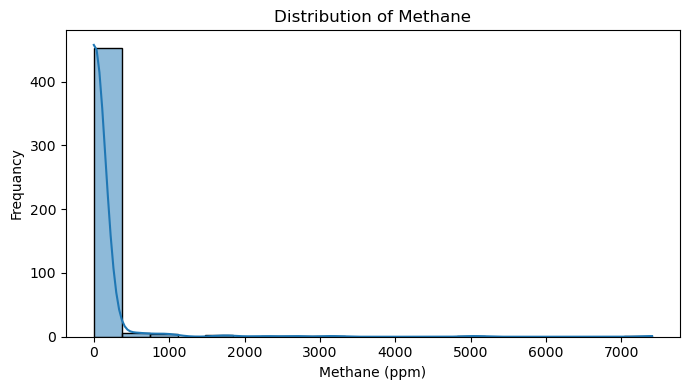

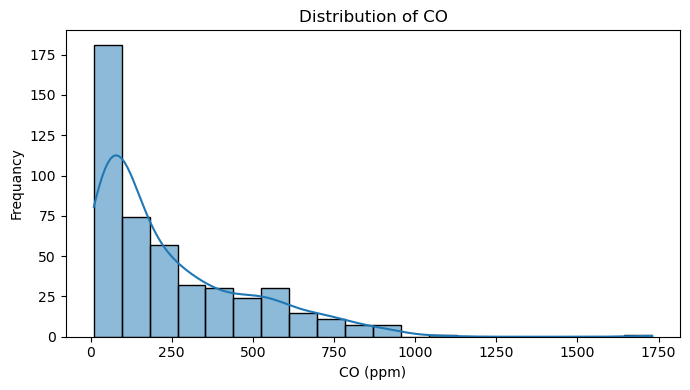

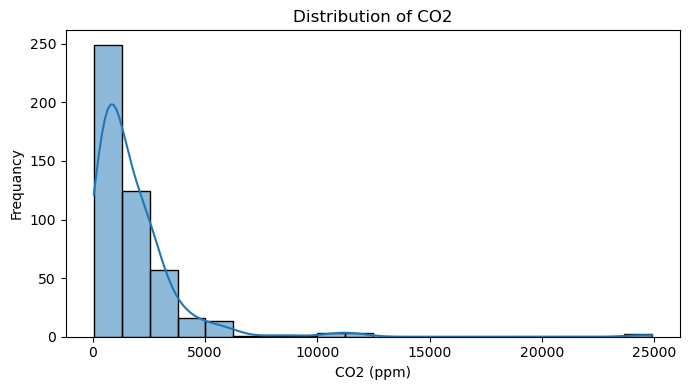

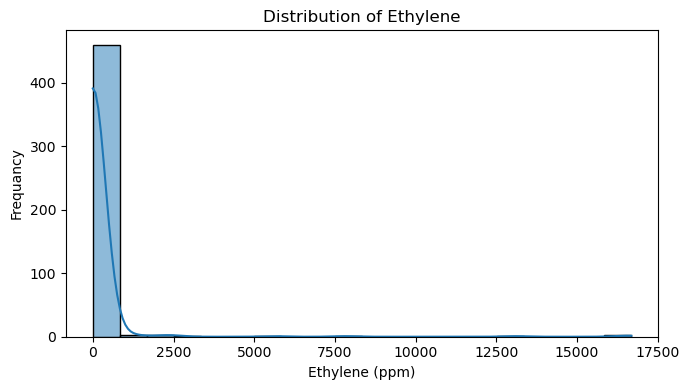

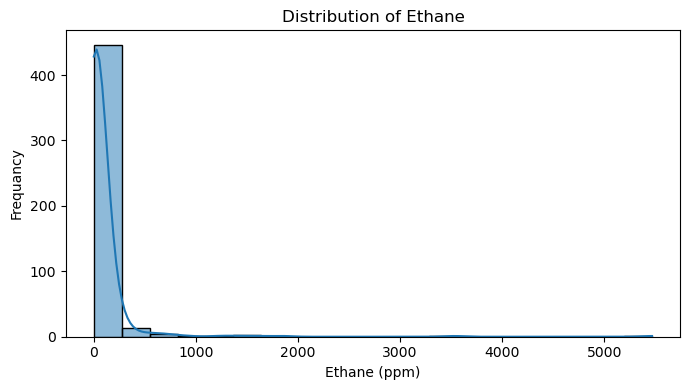

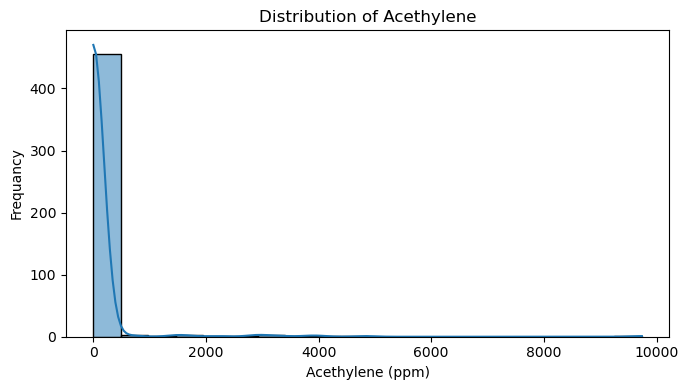

In [36]:
for gas in gas_cols: 
    plt.figure(figsize=(7,4))
    sns.histplot(df[gas], bins=20, kde=True)
    plt.title(f"Distribution of {gas}")
    plt.xlabel(gas + " (ppm)")
    plt.ylabel("Frequancy")
    plt.tight_layout()
    plt.show()

### _DGA Correlation with Health Index_

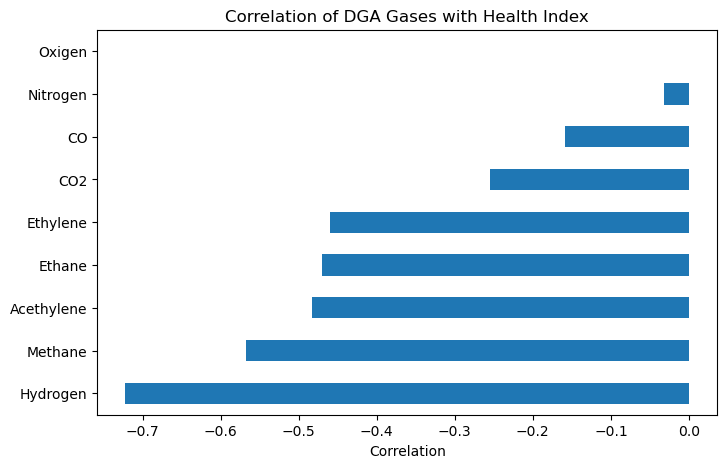

In [37]:
gas_corr = (
    df[gas_cols + ["Health index"]]
    .corr()["Health index"]
    .drop("Health index")
    .sort_values()
)

plt.figure(figsize=(8,5))
gas_corr.plot(kind="barh")

plt.title("Correlation of DGA Gases with Health Index")
plt.xlabel("Correlation")
plt.show()

### _DGA Heatmap_

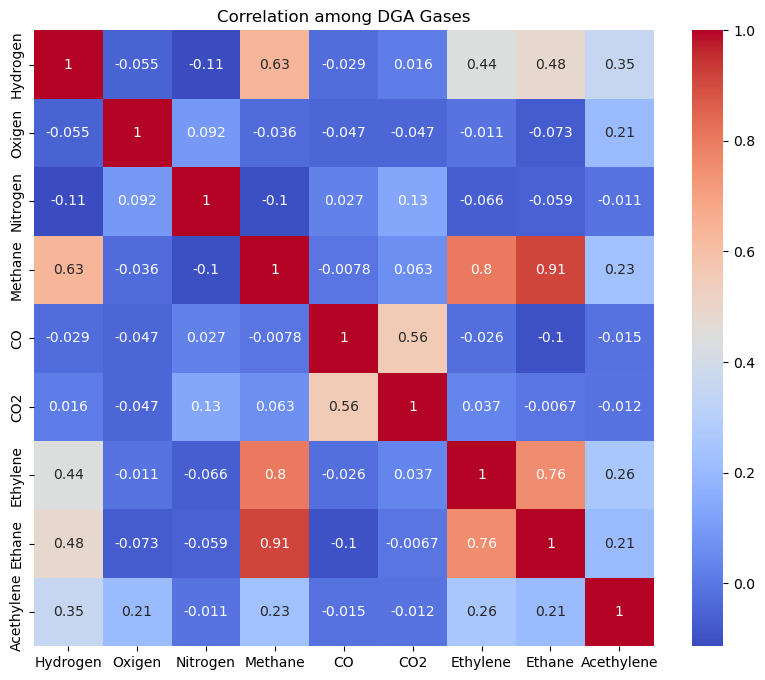

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df[gas_cols].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation among DGA Gases")
plt.show()

#### _DGA by Health Category_

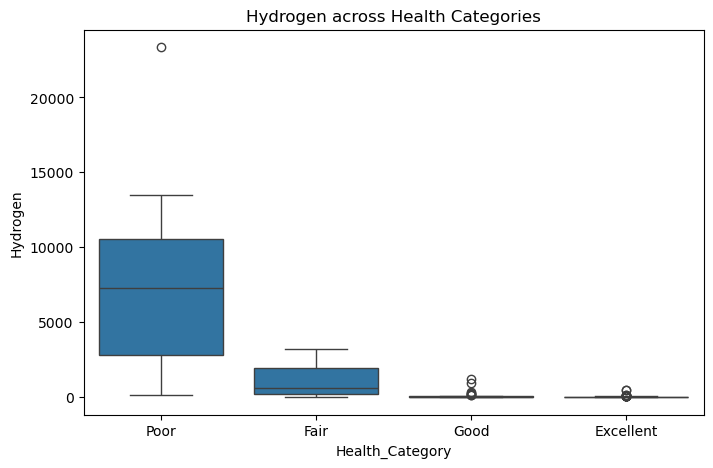

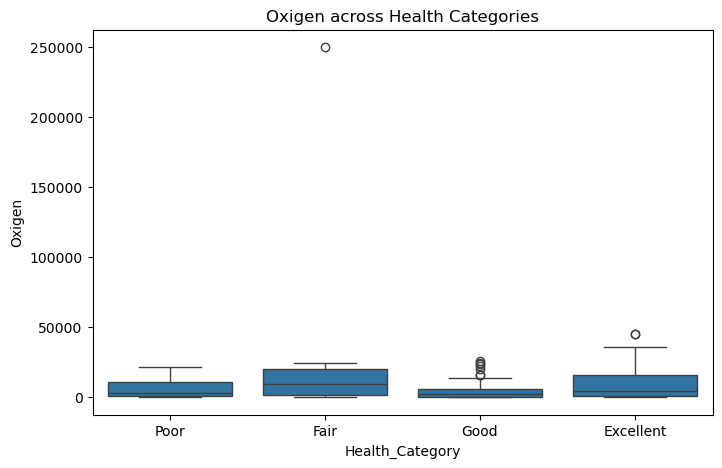

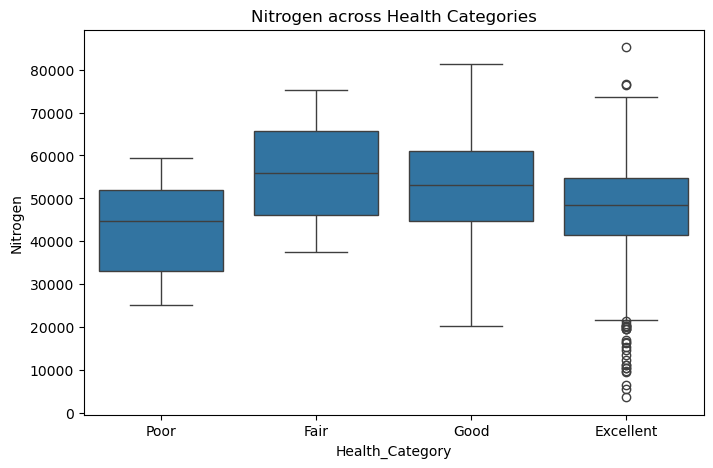

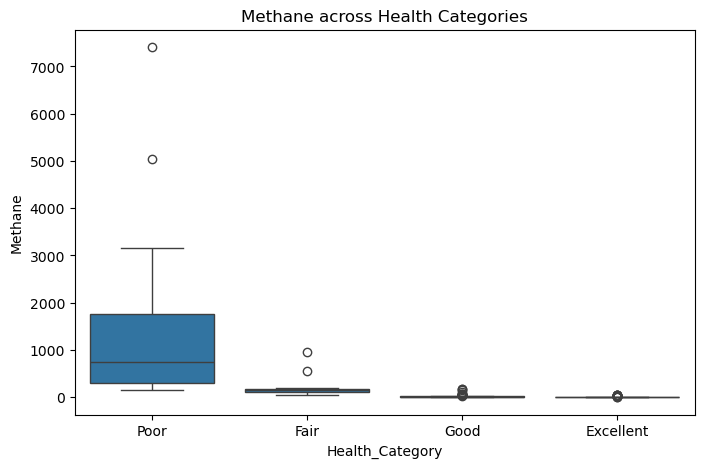

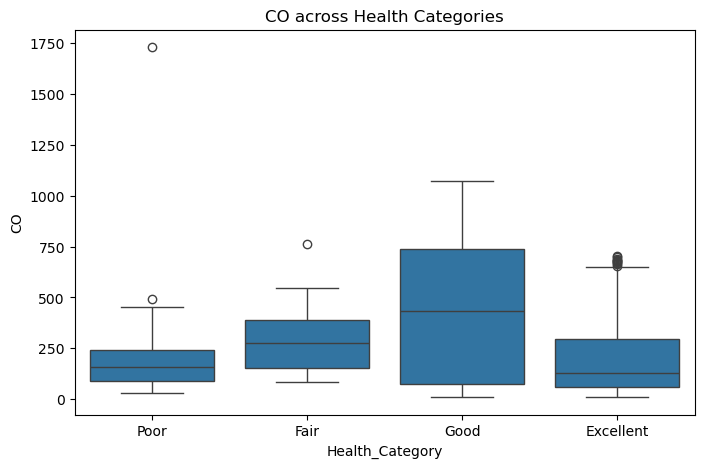

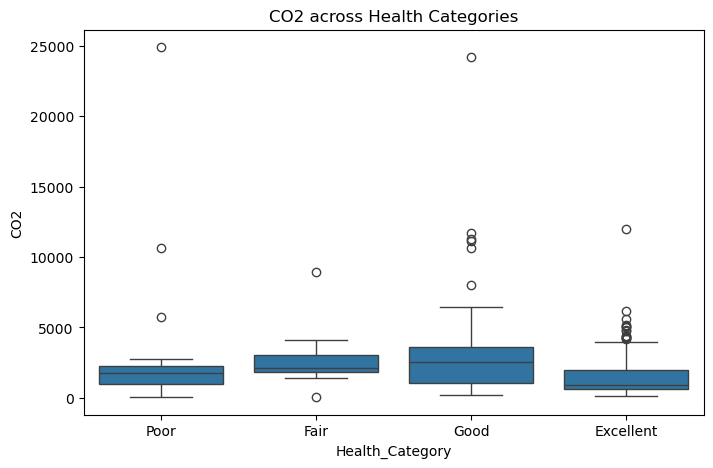

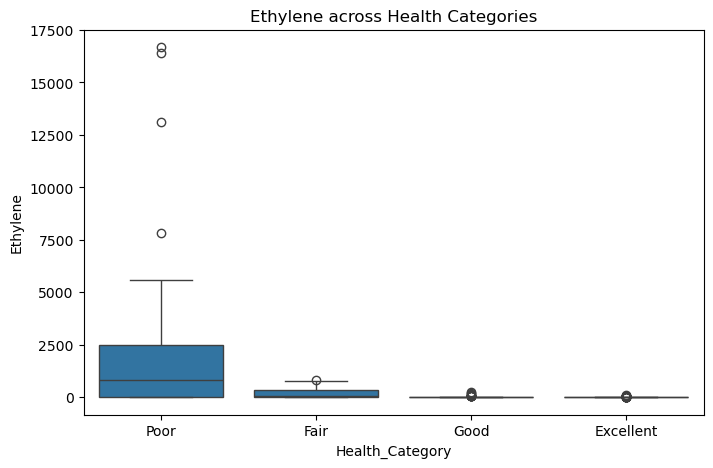

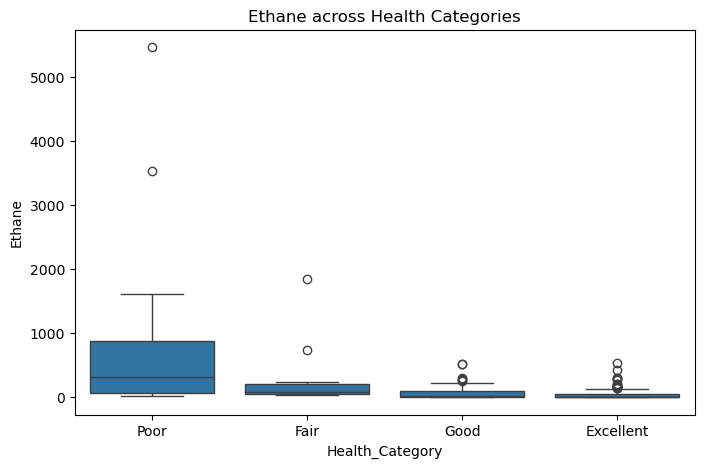

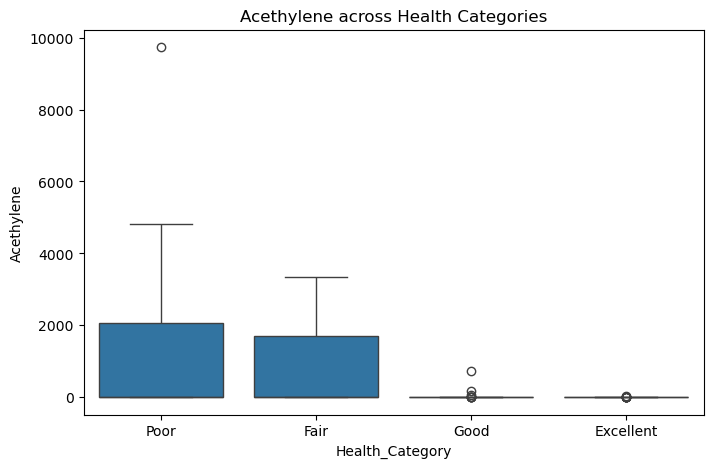

In [71]:
for gas in gas_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        data=df,
        x="Health_Category",
        y=gas
    )
    plt.title(f"{gas} across Health Categories")
    plt.show()

### _Pairplot of important variables_

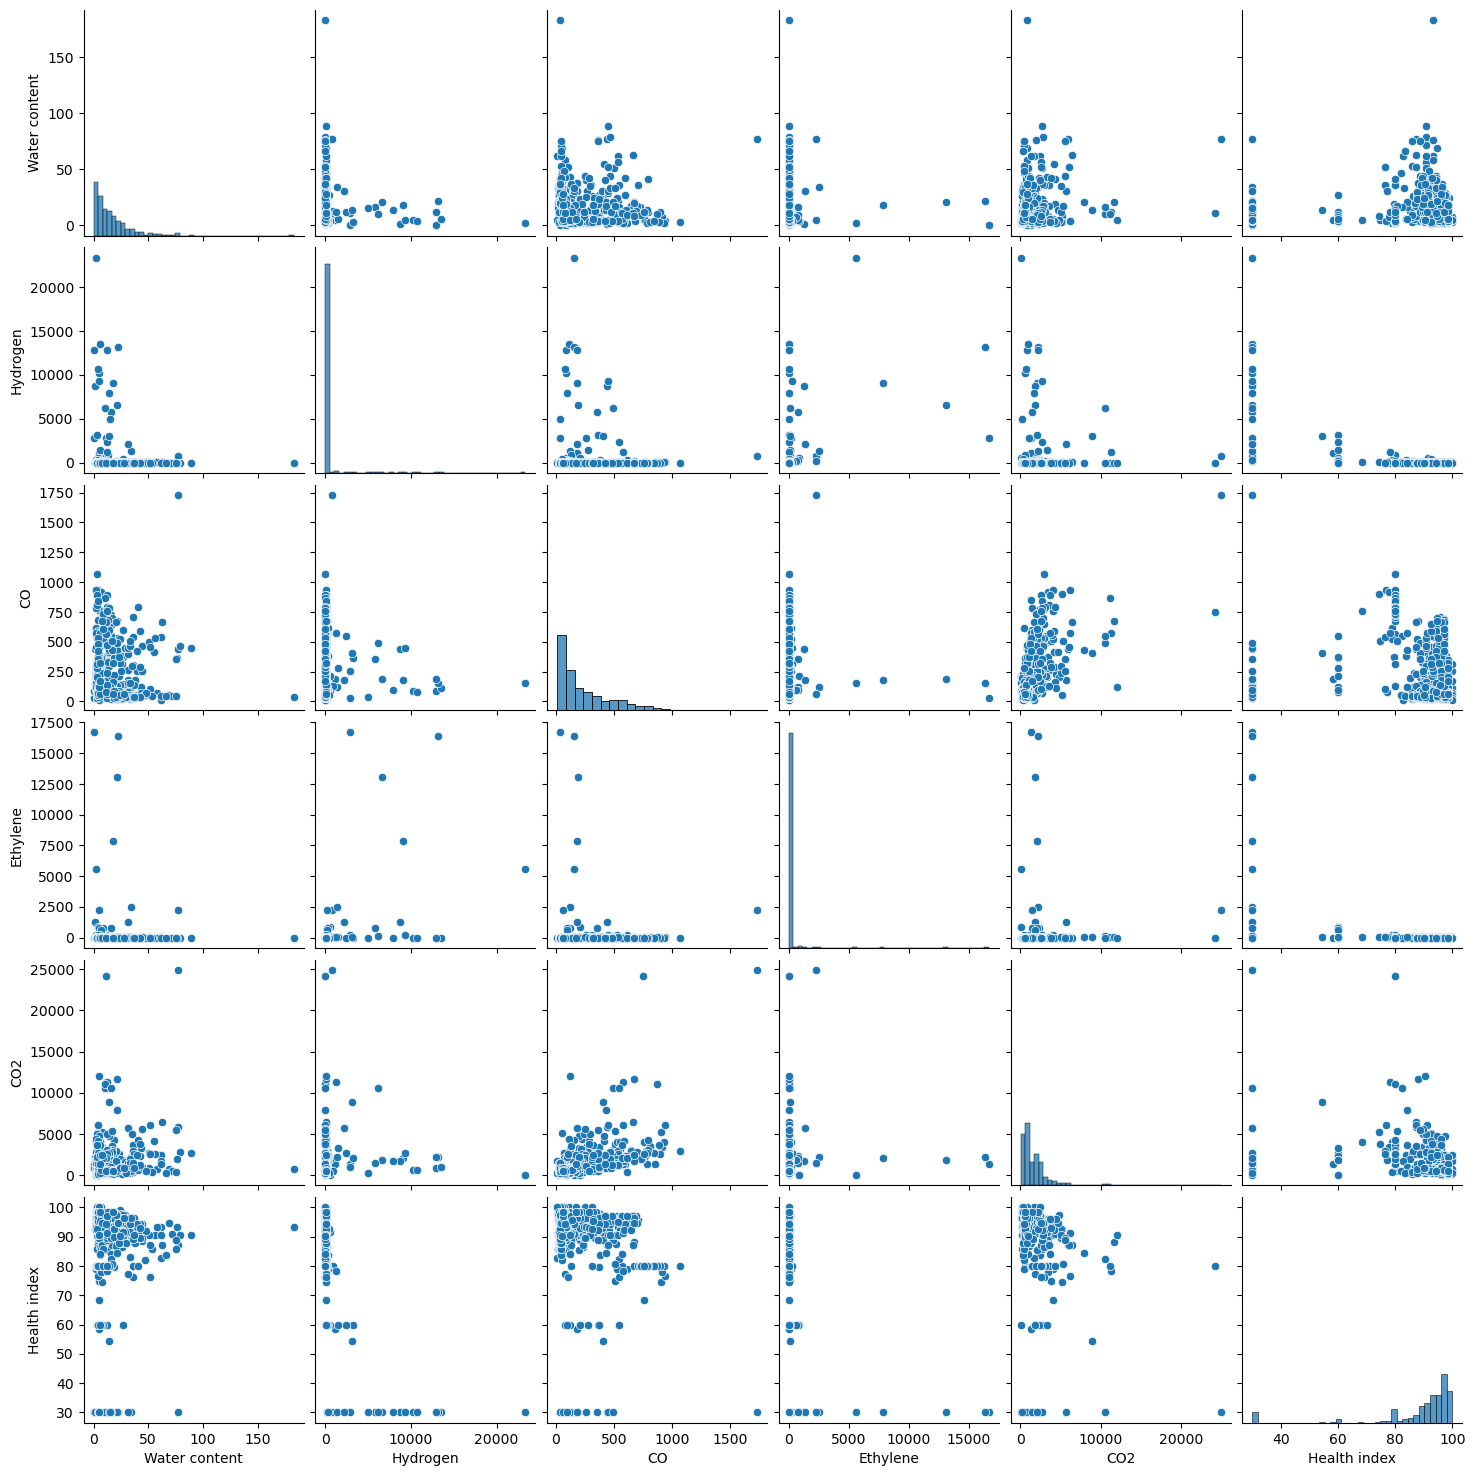

In [41]:
cols = [
    'Water content',
    'Hydrogen',
    'CO',
    'Ethylene',
    'CO2',
    'Health index'
]
sns.pairplot(df[cols])
plt.show()

## Physical Oil Quality & Degradation Check

#### Analyze the distribution of dielectric_rigidity
_dielectric_rigidity (Breakdown Voltage or BDV) measures the insulating strength of transformer oil. if High BDV->Good insulation(in good condition), 
                    Low BDV->Dangerous, contaminated oil(in bad condition)
Unlike gases, where higher values are ofen bad_

In [44]:
df['Dielectric rigidity'].describe()

count    470.000000
mean      53.495745
std        6.458906
min       27.000000
25%       51.000000
50%       54.000000
75%       56.000000
max       75.000000
Name: Dielectric rigidity, dtype: float64

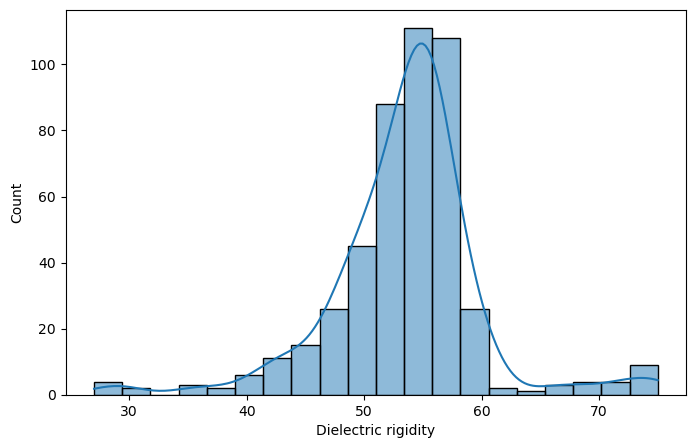

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(df['Dielectric rigidity'], bins=20, kde=True)
plt.show()

### _Find dangerous transformers_

In [47]:
mean_bdv = df['Dielectric rigidity'].mean()
print(mean_bdv)

53.49574468085106


In [48]:
dangerous = df[
    df['Dielectric rigidity'] < mean_bdv - df['Dielectric rigidity'].std()
]
dangerous

,Transformer_ID,Hydrogen,Oxigen,Nitrogen,Methane,CO,CO2,Ethylene,Ethane,Acethylene,DBDS,Power factor,Interfacial V,Dielectric rigidity,Water content,Health index
12,TX_13,254,592,60300,14,376,2500,5,9,0,205.0,0.44,42,42,6,83.9
21,TX_22,1310,2690,51900,1010,119,2220,2520,376,17,0.0,0.25,45,29,34,30.0
22,TX_23,122,294,73100,50,372,2180,69,31,0,168.0,1.27,42,35,19,79.7
23,TX_24,106,581,75200,47,760,4070,11,30,0,183.0,0.16,43,29,5,68.5
27,TX_28,2183,192,43380,1061,183,5730,1308,646,2,0.0,1.00,42,28,31,30.0
28,TX_29,76,324,71700,45,904,5220,10,27,0,227.0,0.45,45,45,8,74.4
36,TX_37,10700,13100,32700,625,79,660,0,190,1,1.0,4.45,42,44,4,30.0
45,TX_46,211,249900,62600,148,118,2300,751,103,3030,0.0,1.00,45,41,9,60.0
63,TX_64,3,1900,81300,37,234,2800,10,102,0,123.0,0.44,41,47,6,86.6
66,TX_67,25,15500,50700,3,267,1180,0,0,0,27.0,1.00,43,43,4,93.8


#### Check relationship between Water content and CO
_Transformer physics says: More moisture -> Paper insulation degrades faster -> More carbon monoxide(CO) produced.
Therefore: water content and CO increase_

In [49]:
df[['Water content', 'CO']].corr()

,Water content,CO
Water content,1.0000,-0.0384
CO,-0.0384,1.0000


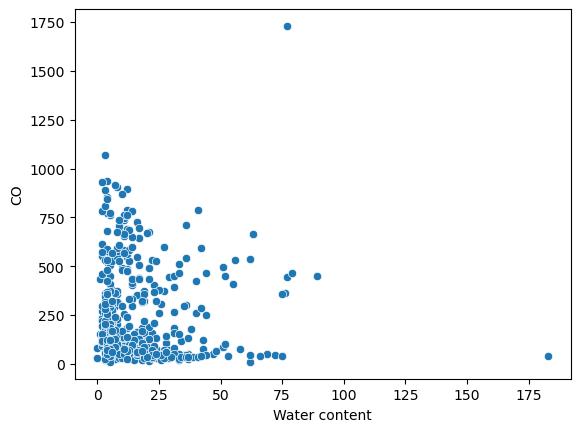

In [50]:
sns.scatterplot(
    x='Water content',
    y='CO',
    data=df
)
plt.show()

#### Check Interfacial Voltage and Power factor
_As transformer oil ages:contamination increases, oxidation products increase,sludge forms. This causes: Power factor increase and Interfacial tension decrease_

In [51]:
df[['Interfacial V', 'Power factor']].corr()

,Interfacial V,Power factor
Interfacial V,1.000000,-0.209686
Power factor,-0.209686,1.000000


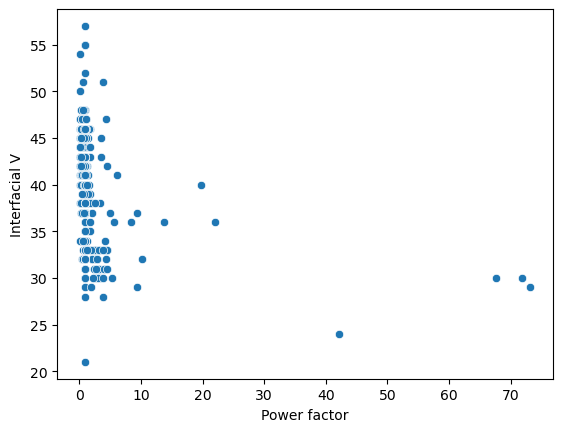

In [52]:
sns.scatterplot(
    x='Power factor',
    y='Interfacial V',
    data=df
)
plt.show()

## Feature-to-Target Correlation Check
_This will tell "Which features are actually useful in predicting the Health Index"_

#### Calculate correlation with the target
_(Assuming target column is Health index)_

In [54]:
corr_target = df.corr(
    numeric_only=True
)['Health index']

#### Rank features

In [55]:
corr_target.abs().sort_values(ascending=False)

Health index           1.000000
Hydrogen               0.722076
Methane                0.566999
Acethylene             0.483558
Ethane                 0.469562
Ethylene               0.460064
Power factor           0.351835
CO2                    0.255477
CO                     0.158643
Dielectric rigidity    0.157329
DBDS                   0.042532
Interfacial V          0.037435
Nitrogen               0.031668
Water content          0.010024
Oxigen                 0.000159
Name: Health index, dtype: float64

#### Identify weak signals

In [56]:
weak_features = corr_target[
    corr_target.abs() < 0.10
]
print("Weak Features:\n",weak_features)

Weak Features:
 Oxigen           0.000159
Nitrogen        -0.031668
DBDS            -0.042532
Interfacial V   -0.037435
Water content   -0.010024
Name: Health index, dtype: float64


#### Pearson vs Spearman

In [57]:
# Pearson 
df.corr(
    method='pearson',
    numeric_only=True
)['Health index'].sort_values(ascending=False)

Health index           1.000000
Dielectric rigidity    0.157329
Oxigen                 0.000159
Water content         -0.010024
Nitrogen              -0.031668
Interfacial V         -0.037435
DBDS                  -0.042532
CO                    -0.158643
CO2                   -0.255477
Power factor          -0.351835
Ethylene              -0.460064
Ethane                -0.469562
Acethylene            -0.483558
Methane               -0.566999
Hydrogen              -0.722076
Name: Health index, dtype: float64

In [60]:
# Spearman 
df.corr(
    method='spearman', numeric_only=True
)['Health index'].sort_values(ascending=False)

Health index           1.000000
Oxigen                 0.203960
Dielectric rigidity    0.180858
Interfacial V          0.098241
Nitrogen              -0.142550
CO                    -0.147397
DBDS                  -0.157754
Water content         -0.160741
Acethylene            -0.315274
Power factor          -0.327016
CO2                   -0.352247
Ethylene              -0.387519
Ethane                -0.387521
Hydrogen              -0.411490
Methane               -0.436907
Name: Health index, dtype: float64

## Creating health categories

In [61]:
df['Health_Category'] = pd.cut(
    df['Health index'],
    bins=[0,49,69,89,100],
    labels=['Poor','Fair','Good','Excellent']
)

In [62]:
df['Health_Category'].value_counts()

Health_Category
Excellent    354
Good          83
Poor          22
Fair          11
Name: count, dtype: int64

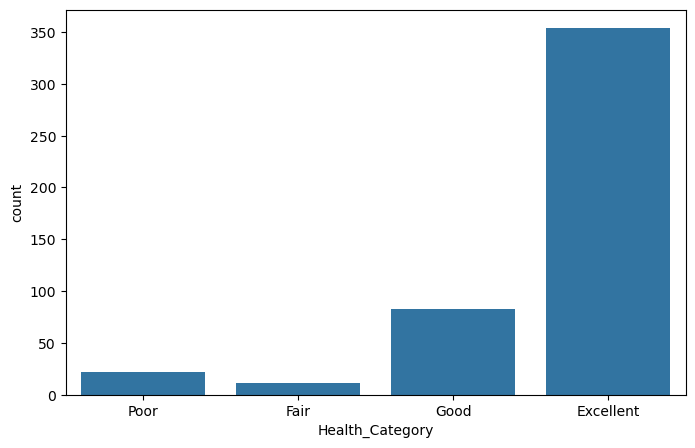

In [64]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Health_Category', data=df
)
plt.show()

## Root Cause Analysis
   (_Identify the operational and oil quality factors most responsible for transformer degradation._)

In [65]:
# Identify High-Risk Transformers 
poor = df[df["Health_Category"] == "Poor"]
poor.describe().T

,count,mean,std,min,25%,50%,75%,max
Hydrogen,22.0,7533.000000,5672.726664,152.00,2826.25,7263.5,10575.0000,23349.00
Oxigen,22.0,6076.136364,6896.642077,61.00,537.25,3127.0,10710.0000,21500.00
Nitrogen,22.0,42846.181818,11261.941656,24991.00,33025.00,44740.0,51900.0000,59400.00
Methane,22.0,1439.772727,1801.636979,142.00,307.25,742.5,1767.5000,7406.00
CO,22.0,253.500000,356.209776,32.00,88.50,156.0,240.2500,1730.00
CO2,22.0,3139.681818,5341.744341,48.00,1008.00,1772.5,2235.0000,24900.00
Ethylene,22.0,3243.727273,5350.211373,0.00,4.25,800.0,2460.0000,16684.00
Ethane,22.0,822.136364,1313.951159,11.00,68.50,312.5,869.7500,5467.00
Acethylene,22.0,1463.681818,2413.980814,0.00,0.00,9.5,2057.5000,9740.00
DBDS,22.0,3.227273,10.150917,0.00,0.00,0.0,1.0000,45.00


#### _Compare Good vs Poor Transformers_

In [67]:
comparison_features = [
    "Water content",
    "CO",
    "Dielectric rigidity",
    "Power factor",
    "Interfacial V"
]
comparison = (
    df.groupby("Health_Category")[comparison_features].mean().round(2)
)
comparison

C:\Users\acer\AppData\Local\Temp\ipykernel_24536\3439559319.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Health_Category")[comparison_features].mean().round(2)


,Water content,CO,Dielectric rigidity,Power factor,Interfacial V
Health_Category,,,,,
Poor,14.27,253.50,51.45,9.57,40.27
Fair,8.73,309.64,49.27,9.43,40.27
Good,20.19,417.35,51.77,2.30,37.41
Excellent,15.73,200.73,54.16,1.03,38.50


#### _Root Cause Visualization_

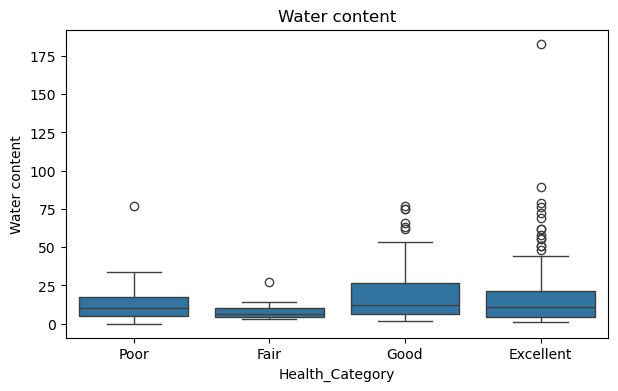

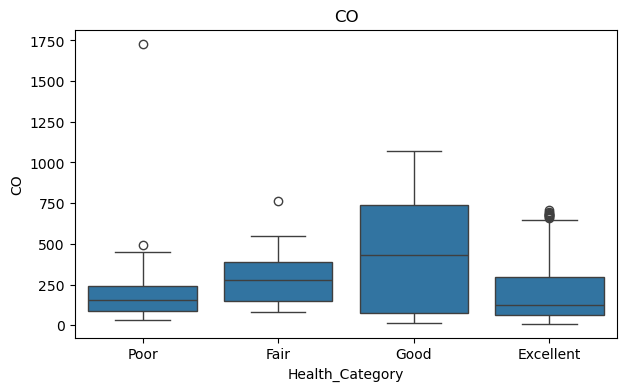

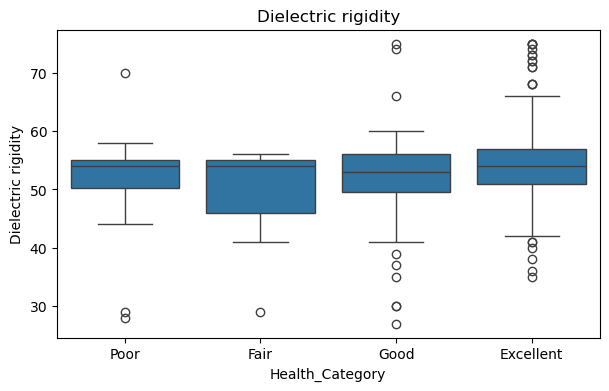

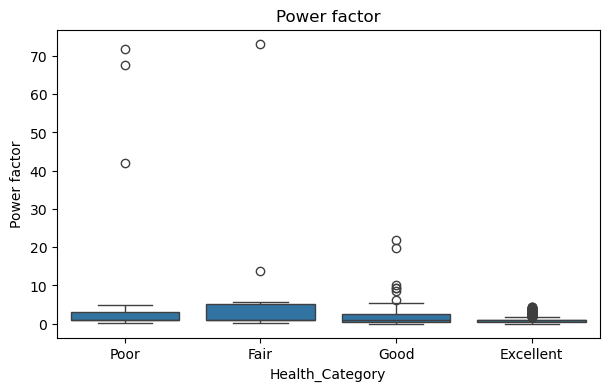

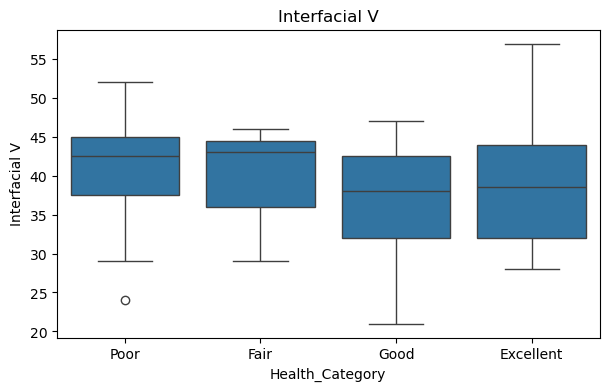

In [68]:
for feature in comparison_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(
        data=df,
        x="Health_Category",
        y=feature
    )
    plt.title(feature)
    plt.show()

#### _Correlation-Based Root Cause Ranking_

In [69]:
root_corr = (
    df.corr(numeric_only=True)["Health index"]
      .sort_values()
)
root_corr

Hydrogen              -0.722076
Methane               -0.566999
Acethylene            -0.483558
Ethane                -0.469562
Ethylene              -0.460064
Power factor          -0.351835
CO2                   -0.255477
CO                    -0.158643
DBDS                  -0.042532
Interfacial V         -0.037435
Nitrogen              -0.031668
Water content         -0.010024
Oxigen                 0.000159
Dielectric rigidity    0.157329
Health index           1.000000
Name: Health index, dtype: float64

## Saving the final cleaned dataset

In [73]:
df.to_csv('../Data/Health_index_final.csv', index=False)